In [3]:
import requests
import pandas as pd
import os
import re
from bs4 import BeautifulSoup as bs
from urllib.parse import urljoin
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

# 기존 데이터 관리 함수
def load_or_init_data():
    filename = '①_통합공지+카테고리분류(3-2-0-2).csv'
    required_columns = [
        '공지분류', '등록 번호', '기본 제목', '공지 제목',
        '부서', '등록일', '조회수', '링크', '본문 내용',
        '이미지 링크', '이미지 텍스트', '마감일자', '모집 현황'
    ]

    if os.path.exists(filename):
        # 1. 기존 파일 불러오기 (필요한 열만 선택)
        df = pd.read_csv(filename, dtype={'등록 번호': str})
        df['등록 번호'] = df['등록 번호'].astype(str)

        # 2. 필요한 열만 남기기 (없는 열은 빈 값으로 생성)
        for col in required_columns:
            if col not in df.columns:
                if col == '조회수':
                    df[col] = 0  # 조회수는 0으로
                elif col in ['등록일', '마감일자']:
                    df[col] = pd.NaT  # 날짜형은 NaT
                else:
                    df[col] = ''  # 문자열은 빈 값

        # 3. 컬럼 순서 보장 및 저장
        df = df[required_columns]
        df.to_csv(filename, index=False, encoding='utf-8-sig')
        return df
    else:
        # 4. 파일이 없으면 빈 DataFrame 생성
        return pd.DataFrame(columns=required_columns)


def get_max_num(existing_df, notice_type):
    filtered = existing_df[
        (existing_df['공지분류'] == notice_type) &
        (existing_df['등록 번호'] != '공지')
    ]

    if filtered.empty:
        return 0

    # 수정된 부분: 문자열 → 숫자 변환 후 최대값 계산
    try:
        nums = pd.to_numeric(filtered['등록 번호'], errors='coerce')
        return int(nums.max())
    except:
        return 0


existing_df = load_or_init_data()
existing_df

일반 = get_max_num(existing_df, '일반공지')
장학 = get_max_num(existing_df, '장학공지')
print(일반, 장학)
existing_df

7547 1108


,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크,본문 내용,이미지 링크,이미지 텍스트,마감일자,모집 현황
0,일반공지,공지,"융합교육지원센터+(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육...","(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전...",융합교육지원센터,2025-05-27,0,https://www.jj.ac.kr/jj/community/notice01.do?...,1.공모전 개요가. 공 모 명: 자기설계연계전공 교육과정 공모전(1차)나. 사업기간...,https://www.jj.ac.kr/_attach/jj/editor-image/2...,전주대학교 교육학신본부 전공과 교라목물 내 아음대로 설계해보사! 자기설계전공 교육과...,2025-06-08,모집중
1,일반공지,공지,예비군연대+2025년도 대학 직장(학생) 예비군 소집훈련 안내문+2025-04-25,2025년도 대학 직장(학생) 예비군 소집훈련 안내문,예비군연대,2025-04-25,0,https://www.jj.ac.kr/jj/community/notice01.do?...,2025년도 대학 직장(학생)예비군 소집훈련 안내문 입니다.2025년도 1학기에 본...,NaN,NaN,-,정보 없음
2,일반공지,7547,"융합교육지원센터+[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육...","[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내",융합교육지원센터,2025-06-02,141,https://www.jj.ac.kr/jj/community/notice01.do?...,NaN,https://www.jj.ac.kr/_attach/jj/editor-image/2...,NaN,2025-06-18,모집중
3,일반공지,7546,대학원 통합행정지원실+2025학년도 1학기 학·석사 연계과정 예비생 모집 안내+20...,2025학년도 1학기 학·석사 연계과정 예비생 모집 안내,대학원 통합행정지원실,2025-06-02,114,https://www.jj.ac.kr/jj/community/notice01.do?...,NaN,https://www.jj.ac.kr/_attach/jj/editor-image/2...,NaN,2025-06-30,모집중
4,일반공지,7545,진로개발센터+2025-1학기 StarT SP장학금 신청 안내+2025-06-02,2025-1학기 StarT SP장학금 신청 안내,진로개발센터,2025-06-02,191,https://www.jj.ac.kr/jj/community/notice01.do?...,NaN,https://www.jj.ac.kr/_attach/jj/editor-image/2...,NaN,2025-07-07,모집중
...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,장학공지,681,교외장학금+2022년도 1학기 선원가족 장학생 선발 안내(3. 1.~4. 8.)+2...,2022년도 1학기 선원가족 장학생 선발 안내(3. 1.~4. 8.),교외장학금,2022-02-17,891,https://www.jj.ac.kr/jj/community/notice03.do?...,<2022년도 1학기 선원가족 장학생 선발 안내>한국선원복지고용센터에서는 선원가족 ...,NaN,NaN,-,정보 없음
929,장학공지,680,교외장학금+2022년 통영시 저소득 대학생 장학금 지원대상자 선발 안내(~2. 25...,2022년 통영시 저소득 대학생 장학금 지원대상자 선발 안내(~2. 25.),교외장학금,2022-02-11,725,https://www.jj.ac.kr/jj/community/notice03.do?...,2022년통영시 저소득 대학생 장학금 지원대상자 선발 공고통영시 인재육성기금 설치 ...,NaN,NaN,2022-02-25,마감
930,장학공지,679,교외장학금+우아한 사장님 자녀 장학금 신청 안내(~2. 20.)+2022-02-11,우아한 사장님 자녀 장학금 신청 안내(~2. 20.),교외장학금,2022-02-11,1352,https://www.jj.ac.kr/jj/community/notice03.do?...,NaN,https://www.jj.ac.kr/_attach/jj/old-editor-ima...,우아한 사장님 자녀 잠학금 지원 신청기간 2022년 2월 7일 (월) ~ 2월 20...,2022-02-20,마감
931,장학공지,678,교외장학금+2022-1학기 국가근로장학사업 희망근로지 신청 안내+2022-02-11,2022-1학기 국가근로장학사업 희망근로지 신청 안내,교외장학금,2022-02-11,5249,https://www.jj.ac.kr/jj/community/notice03.do?...,2022-1학기 국가근로장학사업 희망근로지 신청 안내국가근로장학금은 대학생에게 학자...,NaN,NaN,2022-02-16,마감




> step1. 크롤링 주요 코드



In [4]:
import requests
from bs4 import BeautifulSoup as bs
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime

from datetime import datetime
from urllib.parse import urljoin
import re

File_title = "통합공지"

def crawl_step1(Noti_title, T_limit=500, T_max_pages=1):
    if Noti_title == '일반공지':
        NOTI = '01'
    elif Noti_title == '학사공지':
        NOTI = '02'
    elif Noti_title == '장학공지':
        NOTI = '03'
    else:
        raise ValueError("공지 유형은 '일반공지', '학사공지', '장학공지' 중 하나여야 합니다.")

    def crawl_page(limit, offset,end=0):
        url = f"https://www.jj.ac.kr/jj/community/notice{NOTI}.do?mode=list&&articleLimit={limit}&article.offset={offset}"
        try:
            res = requests.get(url, timeout=5)
            res.encoding = 'utf-8'
            res.raise_for_status()
        except Exception as e:
            print(f"[!] 요청 실패 (offset={offset}) → {e}")
            return []

        soup = bs(res.text, "html.parser")
        box = soup.find("tbody")
        rows = []

        if not box:
            return rows

        for tr in box.find_all("tr"):
            tds = tr.find_all("td")
            if len(tds) < 2:
                continue

            no = tds[0].text.strip()
            if no == str(end):
              break
            content_td = tds[1]

            a_tag = content_td.select_one("div > div > a")
            title = ' '.join(a_tag.stripped_strings) if a_tag else None
            href = a_tag.get("href") if a_tag else None
            link = urljoin(f"https://www.jj.ac.kr/jj/community/notice{NOTI}.do", href) if href else None
            dept_span = content_td.select_one("div > div:nth-of-type(3) > span.b-writer")
            dept = dept_span.text.strip() if dept_span else None
            date_span = content_td.select_one("div > div:nth-of-type(3) > span.b-date")
            date = date_span.text.strip() if date_span else None
            hit_span = content_td.select_one("div > div:nth-of-type(3) > span.b-hit")
            views = int(re.search(r'\d+', hit_span.text.strip()).group()) if hit_span else 0

            if no == "공지":
                #result = extract_notice_body(url)
                if not dept:
                    dept = "관리자"
                date = datetime.today().strftime('%Y-%m-%d')

            prim_key = f"{dept}+{title}+{date}" if title else None

            if title:
                rows.append({
                    "공지분류": Noti_title,
                    "등록 번호": no,
                    "기본 제목": prim_key,
                    "공지 제목": title,
                    "부서": dept,
                    "등록일": date,
                    "조회수": views,
                    "링크": link
                })

        return rows

    def gongji_crawl_parallel(limit=100, max_pages=80):
        offsets = [page * limit for page in range(max_pages)]
        all_rows = []
        end = get_max_num(existing_df, Noti_title)

        with ThreadPoolExecutor(max_workers=10) as executor:
            results = list(executor.map(lambda offset: crawl_page(limit, offset, end), offsets))

        for page_rows in results:
            all_rows.extend(page_rows)

        df = pd.DataFrame(all_rows)
        df.drop_duplicates(subset=["공지 제목", "링크"], inplace=True)
        return df

    print(f"---> step1 시작: {Noti_title}")
    try:
        Tstep1_df = gongji_crawl_parallel(T_limit, T_max_pages)
        print(f"---> step1 완료: {Noti_title}, 총 {len(Tstep1_df)}건")
    except Exception as e:
        print("---> step1 실패")
        print(f"에러 내용: {e}")
        Tstep1_df = pd.DataFrame()

    return Tstep1_df



In [6]:
# ✅ 두 공지 유형 통합 실행
df_general = crawl_step1("일반공지", 500)
df_scholarship = crawl_step1("장학공지", 500)
step1_df = pd.concat([df_general, df_scholarship], ignore_index=True)

step1_df.head(50)

---> step1 시작: 일반공지
---> step1 완료: 일반공지, 총 7건
---> step1 시작: 장학공지
---> step1 완료: 장학공지, 총 13건


,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크
0,일반공지,공지,관리자+<청춘살롱> '전주 청년이 진로를 찾고 길을 묻는 시간' 참가학생 모집+20...,<청춘살롱> '전주 청년이 진로를 찾고 길을 묻는 시간' 참가학생 모집,관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice01.do?...
1,일반공지,공지,관리자+2025학년도 진로 취업 프로그램 인식 및 수요조사(~25. 6. 18.)+...,2025학년도 진로 취업 프로그램 인식 및 수요조사(~25. 6. 18.),관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice01.do?...
2,일반공지,공지,"관리자+(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계...","(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전...",관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice01.do?...
3,일반공지,공지,관리자+2025년도 대학 직장(학생) 예비군 소집훈련 안내문+2025-06-05,2025년도 대학 직장(학생) 예비군 소집훈련 안내문,관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice01.do?...
4,일반공지,7550,산학협력단+[산학협력단] 2025년 하우와우미래캠프 2기 멘티 모집 기간 연장(~6...,[산학협력단] 2025년 하우와우미래캠프 2기 멘티 모집 기간 연장(~6.16.),산학협력단,2025-06-05,57,https://www.jj.ac.kr/jj/community/notice01.do?...
5,일반공지,7549,수퍼스타칼리지+[수퍼스타칼리지] 2025학년도 17회 창의적 글쓰기 경진대회 수상자...,[수퍼스타칼리지] 2025학년도 17회 창의적 글쓰기 경진대회 수상자 안내,수퍼스타칼리지,2025-06-05,100,https://www.jj.ac.kr/jj/community/notice01.do?...
6,일반공지,7548,교수학습개발센터+[교수학습개발센터] 2025-1학기 JJ 코넬노트 경진대회 안내+2...,[교수학습개발센터] 2025-1학기 JJ 코넬노트 경진대회 안내,교수학습개발센터,2025-06-04,196,https://www.jj.ac.kr/jj/community/notice01.do?...
7,장학공지,공지,"관리자+★ 국가근로, 대학생 청소년교육지원사업 휴보강기간 근무 관련 안내(일시적인 ...","★ 국가근로, 대학생 청소년교육지원사업 휴보강기간 근무 관련 안내(일시적인 휴강 근...",관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice03.do?...
8,장학공지,공지,관리자+2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23....,2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시),관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice03.do?...
9,장학공지,공지,"관리자+2025-2학기 국가장학금 신청기간(1차, 5/23~6/23) 안내+2025...","2025-2학기 국가장학금 신청기간(1차, 5/23~6/23) 안내",관리자,2025-06-05,0,https://www.jj.ac.kr/jj/community/notice03.do?...


In [ ]:
step1_df = crawl_step1("학사공지", 1, 1)
step1_df

---> step1 시작: 학사공지
---> step1 완료: 학사공지, 총 5건


,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크
0,학사공지,공지,공지+관리자_(통합모집 단과대학 및 자유전공학부),2025학년도 2학기 학과 선택 안내(통합모집 단과대학 및 자유전공학부),관리자,2025-06-03,0,https://www.jj.ac.kr/jj/community/notice02.do?...
1,학사공지,공지,공지+관리자_ 2학기 전공 선택 안내(학부 해당),2025학년도 2학기 전공 선택 안내(학부 해당),관리자,2025-06-03,0,https://www.jj.ac.kr/jj/community/notice02.do?...
2,학사공지,공지,공지+관리자_2025학년도 2학기 전과 신청 안내,2025학년도 2학기 전과 신청 안내,관리자,2025-06-03,0,https://www.jj.ac.kr/jj/community/notice02.do?...
3,학사공지,공지,공지+관리자_025학년도 하계 계절수업 운영 안내,2025학년도 하계 계절수업 운영 안내,관리자,2025-06-03,0,https://www.jj.ac.kr/jj/community/notice02.do?...
4,학사공지,813,813+융합학부_합·마이크로전공 이수신청 안내(2차),2025학년도 1학기 연계·융합·마이크로전공 이수신청 안내(2차),융합학부,2025-05-14,841,https://www.jj.ac.kr/jj/community/notice02.do?...




> step2. 홈페이지 내용 크롤링



In [7]:
###########################
def extract_notice_body(url):
    """본문 크롤링 + 공지사항 추가 정보 추출 (최종버전)"""
    try:
        res = requests.get(url, timeout=5)
        res.encoding = 'utf-8'
        soup = bs(res.text, "html.parser")

        # 1. 본문 내용 추출
        content_div = soup.select_one("div.b-content-box div.fr-view")
        content = content_div.get_text(separator="", strip=True) if content_div else None

        # 2. 메타 정보 초기화
        meta_info = {'dept': None, 'date': None, 'content': content}

        # 3. 정보 추출 로직 (강화된 버전)
        date_span = soup.select_one("li.b-date-box span:nth-of-type(2)")
        dept_span = soup.select_one("li.b-writer-box span:nth-of-type(2)")

        if date_span:
            meta_info['date'] = date_span.get_text(strip=True)
        if dept_span:
            meta_info['dept'] = dept_span.get_text(strip=True)

        return meta_info

    except Exception as e:
        print(f"[오류 발생] {url} → {e}")
        return {'content': None, 'dept': None, 'date': None}

def add_notice_info_to_df(df):
    """크롤링한 정보를 DataFrame에 입력"""
    temp_df = df.copy()
    contents = []
    depts = []
    dates = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="본문 크롤링 진행"):
        url = row["링크"]
        result = extract_notice_body(url)

        contents.append(result['content'])
        depts.append(result['dept'])
        dates.append(result['date'])

        # 4. 공지사항인 경우 기본 제목 생성
        if row["등록 번호"] == "공지":
            dept = result['dept'] or "관리자"
            date = result['date'] or datetime.today().strftime('%Y-%m-%d')
            title = row["공지 제목"]
            temp_df.at[idx, "기본 제목"] = f"{dept}+{title}+{date}"

    #temp_df["본문 내용"] = contents
    temp_df["부서"] = depts
    temp_df["등록일"] = dates

    return temp_df


In [10]:
# step 2. 공지사항의 [본문내용 카테고리] 열 추가 ---> 시간 약간 소요 됨
print("---> step2 시작")
try:
    step2_df = add_notice_info_to_df(step1_df.head(1))

    # 파일 저장
    file_name = f"step2_{File_title}_(본문내용까지)2.csv"
    step2_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"---> step2 완료 : 저장파일명 = {file_name}")
except Exception as e:
    print("---> step2 실패")
    print(f"에러 내용: {e}")

step2_df

---> step2 시작


본문 크롤링 진행: 100%|██████████| 1/1 [00:01<00:00,  1.02s/it]

---> step2 완료 : 저장파일명 = step2_통합공지_(본문내용까지)2.csv


,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크
0,일반공지,공지,창업지원단+<청춘살롱> '전주 청년이 진로를 찾고 길을 묻는 시간' 참가학생 모집+...,<청춘살롱> '전주 청년이 진로를 찾고 길을 묻는 시간' 참가학생 모집,창업지원단,2025-06-04,0,https://www.jj.ac.kr/jj/community/notice01.do?...


In [ ]:
##################------------------>>> 기존 CSV 수정 코드

import requests
from bs4 import BeautifulSoup as bs
import pandas as pd
from tqdm import tqdm
from datetime import datetime

def extract_notice_body(url):
    """본문 크롤링 + 공지사항 추가 정보 추출 (최종버전)"""
    try:
        res = requests.get(url, timeout=5)
        res.encoding = 'utf-8'
        soup = bs(res.text, "html.parser")

        # 1. 메타 정보 추출
        date_span = soup.select_one("li.b-date-box span:nth-of-type(2)")
        dept_span = soup.select_one("li.b-writer-box span:nth-of-type(2)")

        return {
            'dept': dept_span.get_text(strip=True) if dept_span else None,
            'date': date_span.get_text(strip=True) if date_span else None
        }

    except Exception as e:
        print(f"[오류 발생] {url} → {e}")
        return {'dept': None, 'date': None}

def update_notice_info(df):
    """기존 CSV 업데이트를 위한 함수 (수정버전)"""
    temp_df = df.copy()

    for idx, row in tqdm(temp_df.iterrows(), total=len(temp_df), desc="공지사항 업데이트 중"):
        # 1. 공지사항인 경우 재추출
        if row["등록 번호"] == "공지":
            result = extract_notice_body(row["링크"])

            # 부서 업데이트
            new_dept = result['dept'] or "관리자"
            temp_df.at[idx, "부서"] = new_dept

            # 등록일 업데이트
            new_date = result['date'] or datetime.today().strftime('%Y-%m-%d')
            temp_df.at[idx, "등록일"] = new_date

            # 2. 변경된 값으로 기본 제목 즉시 생성 (수정 부분)
            title = temp_df.at[idx, "공지 제목"]
            temp_df.at[idx, "기본 제목"] = f"{new_dept}+{title}+{new_date}"
        else:
            # 3. 일반 공지도 기본 제목 재생성
            title = row["공지 제목"]
            temp_df.at[idx, "기본 제목"] = f"{row['부서']}+{title}+{row['등록일']}"

    return temp_df


# 사용 예시
existing_df = pd.read_csv("test6.csv")
updated_df = update_notice_info(existing_df)
updated_df.to_csv("업데이트_파일_new.csv", index=False, encoding='utf-8-sig')


공지사항 업데이트 중: 100%|██████████| 23/23 [00:19<00:00,  1.16it/s]


In [ ]:
step2_df

,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크,본문 내용,카테고리
0,학사공지,공지,공지+관리자_(통합모집 단과대학 및 자유전공학부),2025학년도 2학기 학과 선택 안내(통합모집 단과대학 및 자유전공학부),관리자,2025-05-26,0,https://www.jj.ac.kr/jj/community/notice02.do?...,□ 학과 선택: 통합모집 단과대학(인문콘텐츠대학 및 경영대학) 및 수퍼스타칼리지 자...,None




> step3. 이미지 링크 크롤링



In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm
from urllib.parse import urljoin

# 🔹 이미지 링크 추출 함수
def extract_image_links(url):
    try:
        res = requests.get(url, timeout=5)
        res.encoding = 'utf-8'
        soup = BeautifulSoup(res.text, "html.parser")
        img_tags = soup.select("div.b-content-box div.fr-view img")

        # 🔹 이미지 링크 수집
        img_urls = []
        for img in img_tags:
            src = img.get("src")
            if src:
                # 절대경로가 아니면 urljoin으로 붙이기
                full_url = urljoin("https://www.jj.ac.kr", src)
                img_urls.append(full_url)

        # 🔹 리스트가 비어 있으면 None 반환
        if img_urls:
            # 🔸 문자열 형태로 반환 (리스트 [] 제거)
            return ", ".join(img_urls)
        else:
            return None
    except Exception as e:
        print(f"[이미지 크롤링 오류] {url} → {e}")
        return None

# 🔹 데이터프레임 병합 함수
def merge_image_links(df):
    # 이미지 링크 열 추가
    df["이미지 링크"] = None

    # 각 행에 대해 이미지 링크 추출
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        url = row["링크"]
        img_links = extract_image_links(url)
        df.at[idx, "이미지 링크"] = img_links

    return df

In [ ]:
pd.set_option('display.max_colwidth', None)  #데이터의 글자수 제한 해제

# step3. 공지사항에 있는 이미지 파일 링크를 추출하여 "이미지 링크"열 추가
# 약 10분 소요
print("---> step3 시작")
try:
    step3_df = merge_image_links(step2_df)

    # 파일 저장
    file_name = f"step3_{File_title}_(이미지링크까지).csv"
    step3_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"---> step3 완료 : 저장파일명 = {file_name}")
except Exception as e:
    print("---> step3 실패")
    print(f"에러 내용: {e}")
step3_df

---> step3 시작


100%|██████████| 23/23 [00:32<00:00,  1.42s/it]

---> step3 완료 : 저장파일명 = step3_통합공지_(이미지링크까지).csv


,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크,이미지 링크
0,일반공지,공지,"융합교육지원센터+(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)+2025-05-27","(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)",융합교육지원센터,2025-05-27,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480871&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/drEONpgjbFmJiccMNEEgurzTJQ.jpg
1,일반공지,공지,예비군연대+2025년도 대학 직장(학생) 예비군 소집훈련 안내문+2025-04-25,2025년도 대학 직장(학생) 예비군 소집훈련 안내문,예비군연대,2025-04-25,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=479550&article.offset=0&articleLimit=500,None
2,일반공지,7547,"융합교육지원센터_[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내+2025-06-02","[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내",융합교육지원센터,2025-06-02,141,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481187&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/ttOxziViIxfQnDUaHbJunmFPsK.png
3,일반공지,7546,진로개발센터_2025-1학기 StarT SP장학금 신청 안내+2025-06-02,2025-1학기 StarT SP장학금 신청 안내,진로개발센터,2025-06-02,191,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481181&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/yhHGtGwwvqTzlOtoTkMHIDGHBH.png
4,일반공지,7545,대학원 통합행정지원실_2025학년도 1학기 학·석사 연계과정 예비생 모집 안내+2025-06-02,2025학년도 1학기 학·석사 연계과정 예비생 모집 안내,대학원 통합행정지원실,2025-06-02,114,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481126&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/NELSzKMhrQNLDzupEvMVQTvXSN.png
5,일반공지,7544,"창업지원단_「추가모집」 [창업지원단] 2025년 하나 소셜벤처 유니버시티 교육생 추가모집(선착순 모집, 조기마감 예상)+2025-05-30","「추가모집」 [창업지원단] 2025년 하나 소셜벤처 유니버시티 교육생 추가모집(선착순 모집, 조기마감 예상)",창업지원단,2025-05-30,185,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481053&article.offset=0&articleLimit=500,https://jj.ac.kr/_attach/jj/editor-image/2025/05/pFSWIkjBrVcIReVvkaCZItsYJY.png
6,일반공지,7543,융합교육지원센터합교육지원센터_[융합교육지원센터]2025학년도 융합교육 수요조사 안내(기프티콘 제공)+2025-05-30,[융합교육지원센터]2025학년도 융합교육 수요조사 안내(기프티콘 제공),융합교육지원센터합교육지원센터,2025-05-30,214,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480958&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/WfMHnSPQhhsxFPwUWeuixlOGiH.png
7,일반공지,7542,천잠대동제 관리자_[긴급안내] 5월 29일 천잠 대동제 외부인 입장 제한 안내+2025-05-29,[긴급안내] 5월 29일 천잠 대동제 외부인 입장 제한 안내,천잠대동제 관리자,2025-05-29,393,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480948&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/DgKIHjwgMmytclpqaWdzfJVmCs.png
8,일반공지,7541,국제교류원_2025학년도 하계 일본 단기연수 파견학생 선발 안내+2025-05-27,2025학년도 하계 일본 단기연수 파견학생 선발 안내,국제교류원,2025-05-27,611,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480826&article.offset=0&articleLimit=500,None
9,장학공지,공지,교외장학금+2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시)+2025-05-21,2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시),교외장학금,2025-05-21,0,https://www.jj.ac.kr/jj/community/notice03.do?mode=view&articleNo=480596&article.offset=0&articleLimit=500,None


step4. 이미지의 텍스트 인식

In [ ]:
!pip install easyocr
!pip install torch torchvision torchaudio

!apt install -y poppler-utils
!pip install pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
import easyocr
import requests
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from io import BytesIO
from tqdm import tqdm

# 🔹 OCR 모델 초기화
reader = easyocr.Reader(['ko', 'en'])

# 🔹 이미지 링크에서 OCR 수행 함수
def ocr_image_links(img_urls):
    if not img_urls or pd.isna(img_urls):
        return None  # 이미지가 없는 경우

    # 이미지 링크가 여러 개일 수 있으므로 리스트로 변환
    img_list = img_urls.split(", ") if isinstance(img_urls, str) else [img_urls]

    # 🔹 각 이미지에 대해 OCR 수행
    texts = []
    for img_url in img_list:
        try:
            # 이미지 다운로드
            response = requests.get(img_url.strip())
            img = Image.open(BytesIO(response.content))
            img_np = np.array(img)

            # 🔹 OCR 수행
            result = reader.readtext(img_np, detail=0)
            texts.append(" ".join(result))
        except Exception as e:
            print(f"[이미지 OCR 오류] {img_url} → {e}")

    # 🔹 여러 이미지의 텍스트를 합쳐서 반환
    return " ".join(texts) if texts else None

# 🔹 데이터프레임 병합 함수
def df_to_ocr_image_links(df):

    # 각 행에 대해 이미지 링크 추출
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        img_urls = row.get("이미지 링크", "")
        img_texts = ocr_image_links(img_urls)
        df.at[idx, "이미지 텍스트"] = img_texts

    return df

ModuleNotFoundError: No module named 'easyocr'

In [ ]:
# Step4. 시작>> 이미지 파일의 링크를 읽어와서 텍스트 인식 수행
print("---> step4 시작")
try:
    # 🔹 데이터프레임에 이미지 텍스트 병합 (시간 소요 가능)
    step4_df = df_to_ocr_image_links(step3_df.head(3))

    file_name = f"step4_{File_title}_(이미지텍스트까지).csv"
    step4_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"---> step4 완료 : 저장파일명 = {file_name}")
except Exception as e:
    print("---> step4 실패")
    print(f"에러 내용: {e}")

---> step4 시작


  0%|          | 0/3 [00:25<?, ?it/s]


KeyboardInterrupt: 

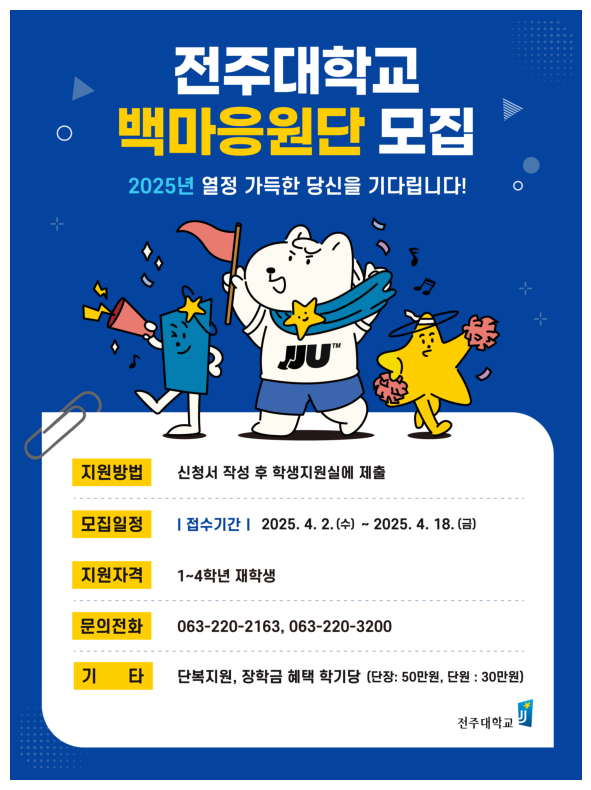


🔍 이미지에서 추출된 텍스트:
전주대학교 백마용원단 모집 2025년 열정 가득한 당신올 기다립니다] TM 3 JU 지원방법 신청서 작성 후 학생지원실에 제출 모집일정 접수기간 | 2025. 4. 2 (수) ~ 2025. 4. 18. (금) 지원자격 1~4학년 재학생 문의전화 063-220-2163, 063-220-3200 기 타 단복지원, 장학금 혜택 학기당 (단장: 50만원, 단원 30만원) 전주대학교


In [ ]:
# ------------------ 각 파일별 OCR 테스트 코드 ----------------------
import easyocr
import requests
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
from io import BytesIO

# 🔹 OCR 모델 초기화
reader = easyocr.Reader(['ko', 'en'])

# 🔹 이미지 URL --> 테스트 할 링크 입력
img_url = "https://www.jj.ac.kr/_attach/jj/editor-image/2025/04/FRIkIxKPnqoxVMcznjlHWiqOrI.png"

# 🔹 이미지 다운로드 및 로드
response = requests.get(img_url)
img = Image.open(BytesIO(response.content))
img_np = np.array(img)

# 🔹 이미지 표시
plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.axis("off")
plt.show()

# 🔹 OCR 수행
result = reader.readtext(img_np, detail=0)
text = " ".join(result)

# 🔹 결과 출력
print("\n🔍 이미지에서 추출된 텍스트:")
print(text)


>step5. 마감일 추가




*   ver.2 - 정확한 마감일만


In [ ]:
import pandas as pd
import re
from datetime import datetime
from dateutil.parser import parse
from typing import Optional
import calendar

def preprocess_text(text: str) -> str:
    """지능형 전처리: 핵심 정보 보존, 노이즈 제거"""
    # 이메일/전화번호 제거 (날짜 패턴 보호)
    text = re.sub(r'\S+@\S+', '', text)  # 이메일
    text = re.sub(r'\d{2,4}-\d{3,4}-\d{4}', '', text)  # 전화번호
    # IR52 같은 코드명은 날짜 형식이 아니면 제거 (숫자-문자 조합, 단일 코드명)
    text = re.sub(r'\b(?!\d+[./]\d+)[A-Za-z]+\d+\b', '', text)
    # 요일 괄호 제거 (수), (금)
    text = re.sub(r'\([^)]*\)', '', text)
    # 날짜 형식 정규화 (2025. 4. 4 → 2025.4.4)
    text = re.sub(r'(\d+)\.\s+(\d+)', r'\1.\2', text)
    # 공백 정규화
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_until_deadline(text: str, base_year: int) -> Optional[str]:
    def build_date(year, month, day):
        try:
            if year < 100: year += 2000  # 2자리 연도 처리
            if 2000 <= year <= 2100 and 1 <= month <= 12 and 1 <= day <= 31:
                return f"{year}-{month:02d}-{day:02d}"
        except: pass
        return None

    text = re.sub(r'\([^)]*\)', '', text)  # 요일 제거

    # 패턴 그룹: (정규식, 그룹 인덱스, 후처리함수)
    patterns = [
        # 1. ~까지 신청/접수/마감
        (r'(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})일?\s*까지\s*(신청|접수|마감)', lambda m: build_date(int(m[1]), int(m[2]), int(m[3]))),

        # 2. YYYY년 MM월 DD일 ~ DD일 학생 모집
        (r'(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})[일\s]*[~\-]+\s*(\d{1,2})[일]?[^\n\r가-힣0-9]*.*?학생\s*모집', lambda m: build_date(int(m[1]), int(m[2]), int(m[4]))),

        # 3. 모집/신청/접수 기간
        (r'(서류\s*접수|접수\s*기간|신청\s*기간|모집\s*기간|모집기간|접수기간|신청기간|지원서\s*접수)[\s:：-]*'
         r'(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})일?\s*~\s*'
         r'(\d{4})?[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})일?',
         lambda m: build_date(int(m[5]) if m[5] else int(m[2]), int(m[6]), int(m[7]))),

        # 4. 마감 키워드 + 날짜
        (r'(마감|접수종료|신청마감)[\s:：]+'
         r'(\d{4})?[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})일?',
         lambda m: build_date(int(m[2]) if m[2] else base_year, int(m[3]), int(m[4]))),

        # 5. 상시모집 ~ 연도.월
        (r'상시모집.*~\s*(\d{4})[./년\s]*(\d{1,2})[월]?',
         lambda m: build_date(int(m[1]), int(m[2]), calendar.monthrange(int(m[1]), int(m[2]))[1])),

        # 6-1: YYYY.MM.DD HH:MM ~ MM.DD HH:MM
        (r'(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2}).*?~\s*'
         r'(\d{1,2})[./월\s]*(\d{1,2})',
         lambda m: build_date(int(m[1]), int(m[4]), int(m[5]))),

        # 6-2: ~YYYY.MM.DD HH:MM까지
        (r'~\s*(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2}).*?(?:까지|시)',
         lambda m: build_date(int(m[1]), int(m[2]), int(m[3]))),

        # 6-3: YYYY.MM.DD HH:MM ~ YYYY.MM.DD HH:MM
        (r'(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2}).*?~\s*'
         r'(\d{4})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})',
         lambda m: build_date(int(m[4]), int(m[5]), int(m[6]))),

        # 6-4: 2자리 연도 ~ 2자리 연도
        (r'(\d{2})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})\s*[~\-]\s*'
         r'(\d{2})[./년\s]*(\d{1,2})[./월\s]*(\d{1,2})',
         lambda m: build_date(2000 + int(m[4]), int(m[5]), int(m[6])))
    ]

    for pattern, extractor in patterns:
        if (match := re.search(pattern, text, re.IGNORECASE)):
            result = extractor(match)
            if result: return result

    return None


def enhanced_extractor(text: str, base_year: int) -> str:
    """최종 추출 엔진 (우선순위 개선)"""
    cleaned_text = preprocess_text(text)


    if deadline := extract_until_deadline(cleaned_text, base_year):
        return deadline


    # 안전하게 '-' 반환
    return '-'


def extract_deadlines(df: pd.DataFrame) -> pd.DataFrame:
    """마감일자 추출 전용 함수"""
    def get_base_year(reg_date: str) -> int:
        try:
            return parse(reg_date, fuzzy=True).year
        except:
            return datetime.now().year

    def process_row(row):
        base_year = get_base_year(str(row.get('등록일', '')))

        # 1. 본문 내용 우선 처리
        main_text = str(row.get('본문 내용', ''))
        deadline = enhanced_extractor(main_text, base_year)
        if deadline != '-':
            return deadline

        # 2. 이미지 텍스트 차선 처리
        image_text = str(row.get('이미지 텍스트', ''))
        deadline = enhanced_extractor(image_text, base_year)
        if deadline != '-':
            return deadline

        # 3. 전체 텍스트 폴백 처리
        combined = ' '.join([
            str(row.get('공지 제목', '')),
            main_text,
            image_text
        ])
        deadline = enhanced_extractor(combined, base_year)
        return deadline

    df['마감일자'] = df.apply(process_row, axis=1)
    df['모집 현황'] = None
    return df

def determine_recruitment_status(df: pd.DataFrame) -> pd.DataFrame:
    """모집현황 판단 전용 함수 (마감일자 컬럼 필요)"""
    def check_priority(row):
        combined_text = ' '.join([
            str(row.get('공지 제목', '')),
            str(row.get('본문 내용', '')),
            str(row.get('이미지 텍스트', ''))
        ])
        deadline = str(row.get('마감일자', '')).strip()

        # 1. 마감일자가 없고 선착순 키워드 포함 시
        if deadline == '-' and '선착순' in combined_text:
            return '선착순'

        # 2. 마감일 기준 모집중/마감 판단
        try:
            if deadline and deadline != '-':
                deadline_date = datetime.strptime(deadline, "%Y-%m-%d").date()
                today = datetime.today().date()
                return '모집중' if deadline_date >= today else '마감'
            return '정보 없음'
        except:
            return '정보 없음'

    df['모집 현황'] = df.apply(check_priority, axis=1)
    return df

In [ ]:
# ===== 테스트 케이스 =====
test_case = {
    '공지 제목': ['학사모니터 모집', 'IR52 설명회'],
    '본문 내용': [
        '1.지원자격-교육과정,학사제도 등 우리 대학 학사 운영에 관심이 있는 재학생(2025학년도8월 졸업자 제외)2.활동계획: 2025. 4.~2025. 12.3.선발인원: 20명 내외/최대4개 팀4.선발방법:팀 구성 현황,주제 확인 등 서류 심사 후 선정5.주제 및 팀 구성가.주제:(학사 운영 전반에 대한)자유 주제1)학사제도 운영 관련 사항(수업 교과과정 등)2)교내 시설(안전사고 예방)및 서비스 관련 사항3)학생자치기구 및 동아리 활동4)대학 내·외 홍보 정책 및 방안5)대학생활 만족도 증진 사항 등나.팀 구성1)동일한 주제와 뜻을 가지고 있는 학생 3~5명으로 팀을 구성2)팀 별 신청을 원칙으로 하며,팀원의 역할 분담이 분명해야 함3)다양한 학과,학년별로 팀 구성 시 선발 우대6.운영방식가.팀별 모니터링 주제 사전 설정나.지원 인원에 따라 최대4개 팀, 20명 내외로 모니터링 인원 선발다.오리엔테이션 및 위촉장 수여:주제 선정 배경 및 모니터링 계획 발표라.선정 주제에 대한 모니터링 실시마.총2차례 정기회의 진행1) 1차 회의:주제 관련 개선 사항 보고 및 추가 개선점 발표2) 2차 회의:모니터링 사항에 대한 최종 보고 및 제안바.기타1)참여 학생은 오리엔테이션과 정기회의(2회)등 학사모니터 활동 관련 모든 일정에 참여 필수2)본인의 팀별 주제 뿐 아니라 다른 팀 주제에 대한 의견 교류,제안도 병행(상호 간의 의견 제시)3)다수의 학생들에게 공통적으로 해당되는 주제 위주로 선정하여 활동7.활동 시 특전가.학사모니터 활동 장학금 학기당40만원 지급(단,모든 일정 참여 필수)나.총장님 명의 위촉장 수여8.진행일정일정내용2025년3월14일학사모니터 운영 계획안 수립 및 보고2025년3월17일~28일학사모니터 학생 모집2025년4월 중학사모니터 학생 선발 및 합격자 발표2025년4월 말학사모니터 오리엔테이션 및 위촉장 수여2025년5월 중학사모니터1차 정기회의(1학기)2025년12월 중학사모니터2차 정기회의(2학기)9. 접수방법: 참가신청서 작성 후 학생지원실 방문 접수 또는 담당자 이메일(ceojinwon@jj.ac.kr) 제출10. 접수문의: 학생지원실 (220-2819 또는 220-2163)',
        ' '
    ],
    '이미지 텍스트': [
        '모집기간: 2025.4.1~4.15',
        '상시모집 2025. 4.~2026. 2 '
            ],
    '등록일': ['2025-04-01', '2025-03-01']
}

df = pd.DataFrame(test_case)
result = extract_deadlines(df)
print(result[['공지 제목', '마감일자']])
result


      공지 제목        마감일자
0  학사모니터 모집  2025-03-28
1  IR52 설명회  2026-02-28


,공지 제목,본문 내용,이미지 텍스트,등록일,마감일자,모집 현황
0,학사모니터 모집,"1.지원자격-교육과정,학사제도 등 우리 대학 학사 운영에 관심이 있는 재학생(2025학년도8월 졸업자 제외)2.활동계획: 2025. 4.~2025. 12.3.선발인원: 20명 내외/최대4개 팀4.선발방법:팀 구성 현황,주제 확인 등 서류 심사 후 선정5.주제 및 팀 구성가.주제:(학사 운영 전반에 대한)자유 주제1)학사제도 운영 관련 사항(수업 교과과정 등)2)교내 시설(안전사고 예방)및 서비스 관련 사항3)학생자치기구 및 동아리 활동4)대학 내·외 홍보 정책 및 방안5)대학생활 만족도 증진 사항 등나.팀 구성1)동일한 주제와 뜻을 가지고 있는 학생 3~5명으로 팀을 구성2)팀 별 신청을 원칙으로 하며,팀원의 역할 분담이 분명해야 함3)다양한 학과,학년별로 팀 구성 시 선발 우대6.운영방식가.팀별 모니터링 주제 사전 설정나.지원 인원에 따라 최대4개 팀, 20명 내외로 모니터링 인원 선발다.오리엔테이션 및 위촉장 수여:주제 선정 배경 및 모니터링 계획 발표라.선정 주제에 대한 모니터링 실시마.총2차례 정기회의 진행1) 1차 회의:주제 관련 개선 사항 보고 및 추가 개선점 발표2) 2차 회의:모니터링 사항에 대한 최종 보고 및 제안바.기타1)참여 학생은 오리엔테이션과 정기회의(2회)등 학사모니터 활동 관련 모든 일정에 참여 필수2)본인의 팀별 주제 뿐 아니라 다른 팀 주제에 대한 의견 교류,제안도 병행(상호 간의 의견 제시)3)다수의 학생들에게 공통적으로 해당되는 주제 위주로 선정하여 활동7.활동 시 특전가.학사모니터 활동 장학금 학기당40만원 지급(단,모든 일정 참여 필수)나.총장님 명의 위촉장 수여8.진행일정일정내용2025년3월14일학사모니터 운영 계획안 수립 및 보고2025년3월17일~28일학사모니터 학생 모집2025년4월 중학사모니터 학생 선발 및 합격자 발표2025년4월 말학사모니터 오리엔테이션 및 위촉장 수여2025년5월 중학사모니터1차 정기회의(1학기)2025년12월 중학사모니터2차 정기회의(2학기)9. 접수방법: 참가신청서 작성 후 학생지원실 방문 접수 또는 담당자 이메일(ceojinwon@jj.ac.kr) 제출10. 접수문의: 학생지원실 (220-2819 또는 220-2163)",모집기간: 2025.4.1~4.15,2025-04-01,2025-03-28,None
1,IR52 설명회,,상시모집 2025. 4.~2026. 2,2025-03-01,2026-02-28,None


In [ ]:
# 예시 데이터 로드
#df_test = pd.read_csv("일반공지+이미지텍스트_포함.csv", encoding='utf-8-sig')  # 또는 merge_image_links 결과

#step5. 시작) 공지 내용에서 마감일 추출하여,[마감일자, 모집현황] 추가
print("---> step5 시작")
try:
    # 🔹 마감일 추출 및 열 추가 (예: "모집 마감일" 등)
    step5_df = extract_deadlines(step3_df.head(500))
    step5_2_df = determine_recruitment_status(step5_df)

    #파일 저장
    file_name = f"step5_{File_title}_(마감일추출포함).csv"
    step5_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"---> step5 완료 : 저장파일명 = {file_name}")
except Exception as e:
    print("---> step5 실패")
    print(f"에러 내용: {e}")

step5_2_df

---> step5 시작
---> step5 완료 : 저장파일명 = step5_통합공지_(마감일추출포함).csv


<ipython-input-16-af77d50d5eae>:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['마감일자'] = df.apply(process_row, axis=1)
<ipython-input-16-af77d50d5eae>:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['모집 현황'] = None
<ipython-input-16-af77d50d5eae>:158: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크,이미지 링크,마감일자,모집 현황
0,일반공지,공지,"융합교육지원센터+(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)+2025-05-27","(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)",융합교육지원센터,2025-05-27,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480871&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/drEONpgjbFmJiccMNEEgurzTJQ.jpg,-,정보 없음
1,일반공지,공지,예비군연대+2025년도 대학 직장(학생) 예비군 소집훈련 안내문+2025-04-25,2025년도 대학 직장(학생) 예비군 소집훈련 안내문,예비군연대,2025-04-25,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=479550&article.offset=0&articleLimit=500,None,-,정보 없음
2,일반공지,7547,"융합교육지원센터_[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내+2025-06-02","[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내",융합교육지원센터,2025-06-02,141,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481187&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/ttOxziViIxfQnDUaHbJunmFPsK.png,-,정보 없음
3,일반공지,7546,진로개발센터_2025-1학기 StarT SP장학금 신청 안내+2025-06-02,2025-1학기 StarT SP장학금 신청 안내,진로개발센터,2025-06-02,191,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481181&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/yhHGtGwwvqTzlOtoTkMHIDGHBH.png,-,정보 없음
4,일반공지,7545,대학원 통합행정지원실_2025학년도 1학기 학·석사 연계과정 예비생 모집 안내+2025-06-02,2025학년도 1학기 학·석사 연계과정 예비생 모집 안내,대학원 통합행정지원실,2025-06-02,114,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481126&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/NELSzKMhrQNLDzupEvMVQTvXSN.png,-,정보 없음
5,일반공지,7544,"창업지원단_「추가모집」 [창업지원단] 2025년 하나 소셜벤처 유니버시티 교육생 추가모집(선착순 모집, 조기마감 예상)+2025-05-30","「추가모집」 [창업지원단] 2025년 하나 소셜벤처 유니버시티 교육생 추가모집(선착순 모집, 조기마감 예상)",창업지원단,2025-05-30,185,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481053&article.offset=0&articleLimit=500,https://jj.ac.kr/_attach/jj/editor-image/2025/05/pFSWIkjBrVcIReVvkaCZItsYJY.png,-,선착순
6,일반공지,7543,융합교육지원센터합교육지원센터_[융합교육지원센터]2025학년도 융합교육 수요조사 안내(기프티콘 제공)+2025-05-30,[융합교육지원센터]2025학년도 융합교육 수요조사 안내(기프티콘 제공),융합교육지원센터합교육지원센터,2025-05-30,214,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480958&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/WfMHnSPQhhsxFPwUWeuixlOGiH.png,-,정보 없음
7,일반공지,7542,천잠대동제 관리자_[긴급안내] 5월 29일 천잠 대동제 외부인 입장 제한 안내+2025-05-29,[긴급안내] 5월 29일 천잠 대동제 외부인 입장 제한 안내,천잠대동제 관리자,2025-05-29,393,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480948&article.offset=0&articleLimit=500,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/DgKIHjwgMmytclpqaWdzfJVmCs.png,-,정보 없음
8,일반공지,7541,국제교류원_2025학년도 하계 일본 단기연수 파견학생 선발 안내+2025-05-27,2025학년도 하계 일본 단기연수 파견학생 선발 안내,국제교류원,2025-05-27,611,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480826&article.offset=0&articleLimit=500,None,-,정보 없음
9,장학공지,공지,교외장학금+2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시)+2025-05-21,2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시),교외장학금,2025-05-21,0,https://www.jj.ac.kr/jj/community/notice03.do?mode=view&articleNo=480596&article.offset=0&articleLimit=500,None,-,정보 없음


In [ ]:
"""-------------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#공비별 카테고리 키워드
일반_공지 = {
    "학사/수업": [
        "수강", "학기", "학점", "교육과정", "졸업", "교과목", "학사", "성적", "교양", "졸업생", "방학",
        "편입", "전공", "교환학생", "학업", "학위", "학력", "복학", "기숙사 입주",
        "학부", "학과", "수업", "실습", "학사", "수강신청", "교육"],
    "진로/취업": [
        "취업", "진로", "채용", "입사", "직무", "일자리", "인턴", "커리어", "직업", "잡콘서트",
        "일자리", "일자리박람회", "커리어"],
    "장학금/지원금": [
        "장학금", "장학", "장학생", "지원금", "학자금지원", "학자금 지원", "근로장학",  "근로 장학", "성적 장학", "성적장학", "등록금 감면", "장학 재단",
        "장학재단", "학비 지원", "학비지원"],
    "대외활동/서포터즈": [
        "서포터즈", "기자단", "홍보대사", "대외활동", "봉사단", "체험단", "멘토단", "자원봉사",
        "자원봉사자", "활동", "캠프", "행사", "봉사활동", "봉사자", "대사", "봉사", "응원단", "자원봉사", "자치기구"],
    "공모전/경진대회": [
        "공모전", "대회", "경진대회", "콘테스트", "아이디어", "캠프", "경진 대회", "해커톤"],
    "교내행사/이벤트": [
        "행사", "축제", "페스티벌", "박람회", "설명회", "콘서트", "캠프", "포럼", "세미나", "이벤트",
        "연합", "학회", "학술제", "학술대회", "워크숍", "온스타", "onSTAR", "초청", "참가자", "기념",
        "설명", "진행", "공연", "심포지엄", "전시", "라이브", "공모전", "경진대회", "문화제", "공연", "음악회",
        "단체 활동", "대동제", "대회", "페어", "파티", "축하", "컨퍼런스"],
    "비교과/교육": [
        "프로그램", "프로그램 안내", "프로그램안내", "지원 프로그램", "특강", "비교과", "워크숍", "세미나", "교육", "학습법",
        "연수", "강좌", "동아리", "소모임", "영어", "스터디", "멘토링", "온스타", "onSTAR", "예치금","역량",
        "과정", "실습", "학습", "역량 강화", "교육과정", "강의", "자격증", "취득", "학습자", "훈련", "강좌", "SP", "CP",
        "자격", "성장", "훈련", "학습법", "기초", "심화", "학점", "교양", "전공", "학습법", "성적", "공부", "실습", "과제"],
    "군 관련": [
        "예비군", "병역", "군입대", "훈련", "복무", "군대", "입대", "전역", "병사", "장교", "부사관", "훈련소",
        "군사", "복무기간", "병역의무", "군생활", "군 입대", "국방", "훈련소", "기초군사훈련", "동원훈련",
        "병역법", "군인", "군복무", "병역제도", "국방부", "예비군 훈련"],
    "창업 관련": [
          "창업", "창업 캠프"],
    "행정" : ["행정", "결과 안내"],
    "기타" : ["%%%%%%%"]
}

장학_공지 = {
    "국가근로장학금": [
  "국가근로장학금", "하계방학집중근로", "동계방학집중근로", "희망근로지 신청", "추가 신청", "1차 신청", "2차 신청", "3차 신청", "신규장학생 운영", "선발 발표", "사전교육", "근로 기간", "근로 장소", "교내근로", "교외근로", "공공기관", "시급", "최대 근로시간", "업무스케쥴", "출근부", "학업시간표 등록", "오리엔테이션", "부정근로", "근로자격 해제", "중복참여 불가", "장학생 준수사항", "근로지 배정", "선호학과", "근로지 담당자", "출근부 어플", "장학금 지급일", "근로지 대학제출", "학적변동", "휴학", "자퇴", "졸업", "제적", "문의", "시스템 오류", "한국장학재단 홈페이지", "모바일 어플"
],
"교내장학금": [
  "가족장학금", "수퍼스타(동문) 자녀 장학금", "다문화장학금", "장애인자녀장학금", "장애대학생장학금", "특수환경지원장학금", "장학사정관제장학금", "재단우대장학금", "신청기간", "신청자격", "성적기준", "이수학점", "평점평균", "제출서류", "가족관계증명서", "개인정보동의서", "장학금액", "지급방법", "inSTAR", "포털", "신규자", "중복수혜", "수업료 감면", "문의", "학생지원실"
],
"교외장학금": [
  "화성시인재육성재단", "하이트진로홀딩스", "강원랜드 멘토링", "전주시 글로벌 인재양성", "인천인재평생교육진흥원", "서울장학재단", "논산시장학회", "농어촌희망재단", "푸른등대 기부장학금", "부산진구장학회", "대산농촌재단", "고속도로장학재단", "은평구민장학재단", "춘천시민장학재단", "손태희장학재단", "협성문화재단", "롯데장학재단", "우아한 사장님 자녀", "미래산업인재", "지역정착 장학금", "해외연수", "해외봉사", "해외유학", "창업기숙사", "꿈드림", "멘토링", "사회리더", "기부장학", "본인부담 등록금 반값지원", "저소득 대학생", "독립유공자 후손", "북한이탈청소년", "소아청소년 당뇨인", "긴급재난 지원", "멘토단", "멘티", "활동기관", "활동계획서", "시급", "최대근로시간", "활동기간", "제출서류", "재단 홈페이지", "추천서"
],
"국가장학금": [
  "국가장학금", "이공계", "인문100년", "예술체육비전", "주거안정장학금", "신청기간", "1차", "2차", "가구원 동의", "소득분위", "지원구간", "성적기준", "신청방법", "서류제출", "지급", "선발", "학업계획서", "학업시간표", "학적변동", "구제신청", "탈락", "문의", "한국장학재단"
],
"학자금대출": [
  "학자금대출", "대출이자 지원", "신용회복 지원", "특별상환유예", "기등록자 특별승인", "농촌출신 학자금융자", "채무자 신고", "해외이주", "유학신고", "업무처리기준", "신청기간", "신청방법", "심사", "지급", "문의", "상환", "학자금지원사업", "결혼이민자", "혼인귀화자", "대학학비지원", "지방자치단체", "농어촌", "이자지원사업", "상환유예", "신용회복"
],
"멘토링/청소년교육지원": [
  "대학생 청소년교육지원사업", "멘토링", "사회리더", "멘토", "멘티", "활동계획서", "활동기관", "사전신청", "사전교육", "활동기간", "활동내용", "시급", "최대근로시간", "중복참여", "부정근로", "선발", "결과발표", "지급", "지급일", "지급방법", "온라인교육", "매뉴얼", "시스템", "어플", "홈페이지", "활동 포기", "기관-학생 상호평가", "출근부", "학업시간표 입력", "업무스케쥴", "활동기관 발굴", "신규기관 등록", "중복참여불가", "이해관계 회피", "활동시간 제한"
],
"특별지원/목회자/북한이탈/보훈": [
  "목회자 장학금", "목회자 자녀 장학금", "북한이탈주민 교육지원금", "보훈장학금", "국가보훈대상자", "국가유공자", "교육지원대상자증명서", "대학수업료등면제대상자증명서", "가족관계증명서", "재직증명서", "교회주보", "결혼이민자", "혼인귀화자", "다문화", "장애인자녀", "장애대학생", "특수환경지원", "아동복지시설", "한부모가정", "긴급재난 지원", "제출서류", "신청기간", "지급방법"
],
"글로벌/해외연수/파란사다리": [
  "글로벌 인재양성", "영어능력강화", "해외연수", "어학연수", "교환학생", "파란사다리", "Fulbright", "국제교류", "신청기간", "선발", "지원", "서류제출", "학점인정", "학적변동", "재단 홈페이지"
],
"취업연계/창업/고졸후학습자/희망사다리": [
  "중소기업 취업연계 장학금", "희망사다리", "고졸후학습자", "창업", "취업", "취업지원", "창업지원", "직무기초교육", "의무종사", "취업연계", "창업지원금", "의무재직", "일자리사업 중복참여", "사용계획서", "진단평가", "보증보험", "취업연계 상담센터", "지원사업", "심사기준", "지원금", "등록금 전액지원", "의무종사 기업기준", "재직확인"
],
"행정/안내/기타": [
  "통학로", "학생지원", "정보로", "안내", "제한대학", "지원대상", "지원방법", "제출서류", "문의", "본인부담", "등록금", "반값지원", "지역정착", "졸업", "휴학", "자퇴", "제적", "졸업예정자", "졸업유예", "학점", "평점", "성적", "학업", "학적변동", "inSTAR", "포털", "이메일", "방문접수", "팩스", "제출기한", "신청기한", "지급기한", "시스템오류", "어플오류", "홈페이지오류", "콜센터", "공지사항", "개인정보동의", "계좌등록", "지급계좌", "통장", "담당자", "연락처"
]
}
학사_공지 = {
    "수업/강의 관련": ["강의", "수업", "교과목", "강의실", "강좌", "시간표", "수강신청", "보강"],
    "시험/평가": ["시험", "수시고사", "중간고사", "기말고사", "평가", "성적", "과제", "응시"],
    "졸업/학위": ["졸업", "논문", "학위", "심사", "학점", "수료", "취업", "조기"],
    "등록/휴학/복학": ["등록", "휴학", "복학", "신청", "복학생", "편입", "자퇴"],
    "장학/재정": ["장학금", "지원", "신청서", "선발", "지급", "장학생"],
    "행사/일정": ["설명회", "일정", "행사", "참석", "기념일", "주간", "날짜", "개강", "종강", "연휴"],
    "행정/공지": ["공지", "안내", "서류", "제출", "처리", "관리", "참조", "변경"]
}
부서_분류 = {
    "학사/수업": ["학생 지원", "학생지원", "학생 역량", "학생역량", "학사지원", "학사 지원", "LINC"],
    "진로/취업":  ["대학 일자리", "대학일자리", "진로취업", "진로 취업", "학생 성공", "학생성공"],
    "장학금/지원금": [],
    "대외활동/서포터즈": [],
    "공모전/경진대회":[],
    "교내행사/이벤트": ["대학 일자리", "대학일자리", "진로취업", "진로 취업" "학생 성공", "학생성공"],
    "비교과/교육": ["대학 일자리", "대학일자리", "진로취업", "진로 취업" "학생 성공", "학생성공"],
    "군 관련": ["예비군"],
}
"""------------------------------------------------------------------------------------------------------------------------------------------------"""

# 🔹 키워드 정의 (간략 버전)
category_dict = {
    "일반공지": 일반_공지,
    "장학공지": 장학_공지
}
department_dict = {
    "일반공지": 부서_분류,
    "장학공지": 부서_분류
}
# 가중치 설정
TITLE_WEIGHT = 3
CONTENT_WEIGHT = 2
DEPT_WEIGHT = 0
IMAGE_WEIGHT = 2

def calculate_category_scores_by_notice_type(df: pd.DataFrame) -> pd.DataFrame:

    def calculate_score(title, content, dept, image, category_keywords, department_keywords):
        title = str(title) if pd.notna(title) else ""
        content = str(content) if pd.notna(content) else ""
        dept = str(dept) if pd.notna(dept) else ""
        image = str(image) if pd.notna(image) else ""

        scores = {k: 0 for k in category_keywords.keys()}

        for cat, keywords in category_keywords.items():
            scores[cat] += (sum(title.count(k) for k in keywords) * TITLE_WEIGHT * 10) / (len(title) + 1)
            scores[cat] += (sum(content.count(k) for k in keywords) * CONTENT_WEIGHT * 10) / (len(content) + 1)
            scores[cat] += (sum(image.count(k) for k in keywords) * IMAGE_WEIGHT * 10) / (len(image) + 1)

        for cat, keywords in department_keywords.items():
            if cat in scores:
                scores[cat] += (sum(dept.count(k) for k in keywords) * DEPT_WEIGHT * 10) / (len(dept) + 1)

        if all(v == 0 for v in scores.values()):
            scores["기타"] = 1.0

        return scores

    # 점수 계산 및 열 추가
    result_df = df.copy()
    for idx, row in result_df.iterrows():
        noti_type = row.get("공지분류", "").strip()
        category_keywords = category_dict.get(noti_type, {})
        department_keywords = department_dict.get(noti_type, {})

        title = row.get("공지 제목", "")
        content = row.get("본문 내용", "")
        dept = row.get("부서", "")
        image = row.get("이미지 텍스트", "")

        scores = calculate_score(title, content, dept, image, category_keywords, department_keywords)

        for cat, score in scores.items():
            colname = f"{noti_type}_{cat}"
            if colname not in result_df.columns:
                result_df[colname] = 0.0
            result_df.at[idx, colname] = score

    return result_df

# 필수 컬럼 리스트 (순서 보장)
required_columns = [
    '공지분류', '등록 번호', '기본 제목', '공지 제목',
    '부서', '등록일', '조회수', '링크', '본문 내용',
    '이미지 링크', '이미지 텍스트', '마감일자', '모집 현황'
]

# 누락된 컬럼 추가
def index_test(df: pd.DataFrame) -> pd.DataFrame:
  for col in required_columns:
      if col not in df.columns:
          # 데이터 타입에 맞게 초기화
          if col == '조회수':
              df[col] = 0  # 숫자형
          elif col in ['등록일', '마감일자']:
              df[col] = pd.NaT  # 날짜형
          else:
              df[col] = ''  # 문자열
  return df
df6 = index_test(step5_2_df)
# 컬럼 순서 재정렬
df6 = df6.reindex(columns=required_columns)
df6.to_csv("test6.csv", index=False, encoding='utf-8-sig')

#step6. 카테고리분류 지정
print("---> step6 시작")
try:
    step6_df = calculate_category_scores_by_notice_type(df6)

    #파일 저장
    step6_df.to_csv(f"step6_update통합공지.csv", index=False, encoding='utf-8-sig')
    print(f"---> step6 완료 : 저장파일명 = ①1_통합공지_카테고리분류")
except Exception as e:
    print("---> step6 실패")
    print(f"에러 내용: {e}")


# 🔹 최종 데이터프레임 출력
step6_df

---> step6 시작
---> step6 완료 : 저장파일명 = ①1_통합공지_카테고리분류


,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크,본문 내용,이미지 링크,...,장학공지_국가근로장학금,장학공지_교내장학금,장학공지_교외장학금,장학공지_국가장학금,장학공지_학자금대출,장학공지_멘토링/청소년교육지원,장학공지_특별지원/목회자/북한이탈/보훈,장학공지_글로벌/해외연수/파란사다리,장학공지_취업연계/창업/고졸후학습자/희망사다리,장학공지_행정/안내/기타
0,일반공지,공지,"융합교육지원센터+(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)+2025-05-27","(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)",융합교육지원센터,2025-05-27,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480871&article.offset=0&articleLimit=500,,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/drEONpgjbFmJiccMNEEgurzTJQ.jpg,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,일반공지,공지,예비군연대+2025년도 대학 직장(학생) 예비군 소집훈련 안내문+2025-04-25,2025년도 대학 직장(학생) 예비군 소집훈련 안내문,예비군연대,2025-04-25,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=479550&article.offset=0&articleLimit=500,,None,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,일반공지,7547,"융합교육지원센터_[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내+2025-06-02","[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내",융합교육지원센터,2025-06-02,141,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481187&article.offset=0&articleLimit=500,,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/ttOxziViIxfQnDUaHbJunmFPsK.png,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,일반공지,7546,진로개발센터_2025-1학기 StarT SP장학금 신청 안내+2025-06-02,2025-1학기 StarT SP장학금 신청 안내,진로개발센터,2025-06-02,191,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481181&article.offset=0&articleLimit=500,,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/yhHGtGwwvqTzlOtoTkMHIDGHBH.png,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,일반공지,7545,대학원 통합행정지원실_2025학년도 1학기 학·석사 연계과정 예비생 모집 안내+2025-06-02,2025학년도 1학기 학·석사 연계과정 예비생 모집 안내,대학원 통합행정지원실,2025-06-02,114,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481126&article.offset=0&articleLimit=500,,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/NELSzKMhrQNLDzupEvMVQTvXSN.png,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,일반공지,7544,"창업지원단_「추가모집」 [창업지원단] 2025년 하나 소셜벤처 유니버시티 교육생 추가모집(선착순 모집, 조기마감 예상)+2025-05-30","「추가모집」 [창업지원단] 2025년 하나 소셜벤처 유니버시티 교육생 추가모집(선착순 모집, 조기마감 예상)",창업지원단,2025-05-30,185,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481053&article.offset=0&articleLimit=500,,https://jj.ac.kr/_attach/jj/editor-image/2025/05/pFSWIkjBrVcIReVvkaCZItsYJY.png,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,일반공지,7543,융합교육지원센터합교육지원센터_[융합교육지원센터]2025학년도 융합교육 수요조사 안내(기프티콘 제공)+2025-05-30,[융합교육지원센터]2025학년도 융합교육 수요조사 안내(기프티콘 제공),융합교육지원센터합교육지원센터,2025-05-30,214,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480958&article.offset=0&articleLimit=500,,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/WfMHnSPQhhsxFPwUWeuixlOGiH.png,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,일반공지,7542,천잠대동제 관리자_[긴급안내] 5월 29일 천잠 대동제 외부인 입장 제한 안내+2025-05-29,[긴급안내] 5월 29일 천잠 대동제 외부인 입장 제한 안내,천잠대동제 관리자,2025-05-29,393,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480948&article.offset=0&articleLimit=500,,https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/DgKIHjwgMmytclpqaWdzfJVmCs.png,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,일반공지,7541,국제교류원_2025학년도 하계 일본 단기연수 파견학생 선발 안내+2025-05-27,2025학년도 하계 일본 단기연수 파견학생 선발 안내,국제교류원,2025-05-27,611,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480826&article.offset=0&articleLimit=500,,None,...,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,장학공지,공지,교외장학금+2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시)+2025-05-21,2025-2학기 국가근로장학금 1차 신청 안내(5. 23. 9시~6. 23. 18시),교외장학금,2025-05-21,0,https://www.jj.ac.kr/jj/community/notice03.do?mod

In [ ]:
### 최종

ttest = pd.read_csv("test7 (3).csv", encoding='utf-8-sig')
final_df = determine_recruitment_status(ttest)
#step8. 카테고리분류 지정
print("---> step6 시작")
try:
    step8_df = calculate_category_scores_by_notice_type(final_df)

    #파일 저장
    step8_df.to_csv(f"step8_update①_통합공지_카테고리분류.csv", index=False, encoding='utf-8-sig')
    print(f"---> step8 완료 : 저장파일명 = ①_통합공지_카테고리분류")
except Exception as e:
    print("---> step8 실패")
    print(f"에러 내용: {e}")


# 🔹 최종 데이터프레임 출력

---> step6 시작
---> step8 완료 : 저장파일명 = ①_통합공지_카테고리분류


In [ ]:
import pandas as pd
df6 = pd.read_csv("업데이트_파일_new.csv", encoding='utf-8-sig')

def merge_notice_data(new_df: pd.DataFrame, existing_df: pd.DataFrame) -> pd.DataFrame:
    merged_total_df = pd.DataFrame()
    category_list = new_df["공지분류"].unique()

    for category in category_list:
        df6 = new_df[new_df["공지분류"] == category].copy()
        ex_df = existing_df[existing_df["공지분류"] == category].copy()

        # Step 1: 공지 항목 비교 및 Dump 처리
        df6_titles = set(df6[df6["등록 번호"] == "공지"]["기본 제목"])
        ex_df["등록 번호"] = ex_df.apply(
            lambda row: "Dump" if row["등록 번호"] == "공지" and row["기본 제목"] not in df6_titles else row["등록 번호"],
            axis=1,
        )

        # Step 2: 공지 항목 통합 - 기존 데이터를 먼저 유지
        noti_df = pd.concat([
            ex_df[ex_df["등록 번호"] == "공지"],
            df6[df6["등록 번호"] == "공지"]
        ])
        noti_df = noti_df.drop_duplicates(subset=["기본 제목"], keep="first")

        # Step 3: 공지가 아닌 항목 통합 및 번호 재정렬
        df6_normal = df6[df6["등록 번호"] != "공지"]
        ex_df_normal = ex_df[ex_df["등록 번호"] != "공지"]

        # df6에만 있고 existing에는 없는 행만 남기기
        duplicate_titles = set(df6_normal["기본 제목"]) & set(ex_df_normal["기본 제목"])
        df6_normal = df6_normal[~df6_normal["기본 제목"].isin(duplicate_titles)]

        combined_normal = pd.concat([df6_normal, ex_df_normal])
        combined_normal = combined_normal.drop_duplicates(subset=["기본 제목"], keep="first")

        # 등록일 내림차순 정렬
        combined_normal["등록일"] = pd.to_datetime(combined_normal["등록일"], errors="coerce")
        combined_normal = combined_normal.sort_values("등록일", ascending=False)

        # 등록번호 재정렬
        try:
            top_number = int(df6[df6["등록 번호"] != "공지"]["등록 번호"].astype(int).max())
        except:
            top_number = 9999  # fallback

        new_numbers = list(range(top_number, top_number - len(combined_normal), -1))
        combined_normal["등록 번호"] = new_numbers

        # 형식 맞추기
        combined_normal["등록일"] = combined_normal["등록일"].dt.strftime("%y-%m-%d")

        # 최종 병합
        final_df = pd.concat([noti_df, combined_normal])
        merged_total_df = pd.concat([merged_total_df, final_df])

    return merged_total_df.reset_index(drop=True)

result_df = merge_notice_data(df6, existing_df)
result_df.to_csv("test7.csv", index=False, encoding='utf-8-sig')
result_df

,공지분류,등록 번호,기본 제목,공지 제목,부서,등록일,조회수,링크,본문 내용,이미지 링크,이미지 텍스트,마감일자,모집 현황
0,일반공지,공지,"융합교육지원센터+(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)+2025-05-27","(총상금 3,000,000원)2025학년도 1학기 자기설계전공 교육과정 설계 공모전 안내(1차)",융합교육지원센터,2025-05-27,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=480871&article.offset=0&articleLimit=100,"1.공모전 개요가. 공 모 명: 자기설계연계전공 교육과정 공모전(1차)나. 사업기간: 2025. 5.∼2025. 12.1) 제출기간: 2025. 5. 26.(월) ~ 6. 8.(일)2) 심사기간: 2025. 6. 9.(월) ~ 6. 13.(금)3) 발표평가 기간: 추후 공지4) 시상식: 2025. 6. 13.(금) 예정* 상기 일정은 교내 사정에 의해 변경될 수 있습니다.다. 주요내용: 학생 수요 맞춤형 교육과정 설계 공모 및 시상라. 지원대상: 본교 1~3학년 재학생1) 연계전공 이수 가능자(4학년도 가능하나, 이수를 위한 학점취득 고려)2) 상금 지급대상(직전학기 12학점 이상 취득 및 평점평균 2.5점 이상)2. 공모 내용가. 교육과정 편성 기준: 45학점 이상나. 신청방법: [양식#1] 자기설계연계전공 교육과정 공모전 신청서, 자유양식 발표자료(PPT) 제출다. 제출처: 융합교육지원센터 담당자 이메일(goodday1318@jj.ac.kr)라. 교육과정 편성 방법(아래 방법 중 하나를 선택하거나 혼합하여 편성도 가능)_교육과정 편람 참조(클릭)구분내용[유형1]모듈형기존에 개설된 마이크로전공 교육과정을 3~4개 연계한 모듈형 교육과정 설계[유형2]신산업 맞춤형기존의 연계전공, 융합전공, 마이크로전공의 교육과정을 신산업(AI, 에너지, 2차전지 등) 수요에 맞게 보완하고, 발전시킨 교육과정 설계[유형3]자유형교내 개설된 교과목을 진로분야와 개인 선호에 따라 자유롭게 교육과정 설계3. 상장수여 및 상금상급수상인원상금상급별 상금 합계상훈대상1명600,000원600,000원총장상최우수상2명300,000원600,000원총장상우수상4명200,000원800,000원대학혁신지원사업단장상장려상10명100,000원1,000,000원대학혁신지원사업단장상합계3,000,000원※ 경진대회 상금은 ‘장학금’이 아닌 ‘기타소득’으로 분류※ 대상, 최우수상 수상자는 설계한 전공을 이수하여야 함※ 공모에 참여한 내용은 수상하지 않더라도, 교육과정으로 활용될 수 있음4. 기타사항가. 교육과정 공모전은 자기설계연계전공 이수신청이 아니며, 자기설계연계전공 참여 및 이수를 위해서는지도교수 확인서 등 별도 서류 제출 필요나. 공모전 참여 후 전공 개설, 이수 신청까지 참여하여 자기설계 연계전공으로 참여할 수 있음다. 전공설계는 학교에 개설된 모든 교과목을 활용하여 자유롭게 구성하거나 기존의 학과 및 연계·융합·마이크로전공 교육과정을 기반으로 설계할 수 있으며, 학생의 관심과 수요가 높은 자기설계전공은 융합학부의 연계·융합전공으로 개설되어 활용될 수 있음라. 우수 교육과정이 없을 시 전부 또는 일부 선발하지 않을 수 있음마. 타 대학 사례 표절, 아이디어 도용 등이 확인될 경우 시상하지 않으며, 시상금이 지급되었더라도 환수할 수 있음5. 문의안내: 융합교육지원센터 담당자(063-220-2835)",https://www.jj.ac.kr/_attach/jj/editor-image/2025/05/drEONpgjbFmJiccMNEEgurzTJQ.jpg,"전주대학교 교육학신본부 전공과 교라목물 내 아음대로 설계해보사! 자기설계전공 교육과정 설계 공모전 5. 26.-6.9 U 공모내용 자기설계전공 교육과정설계 공모 * 우리 대학에 개설되지 않은 전공과 전공 교육과정을 스스로 설계 * 설계한 교육과정올 복수전공으로 이수 공모대상 전주대학교 1~3학년 재학생 공모 세부내용 * 연계전공 이수 가능자(4학년도 가능하나 이수름 위한 학점취득 고려) * 상금 지급대상(직전학기 12학점 이상 취득 및 평점평균 2.5점 이상) * 1학년은 학점 상관없이 지원 가능 교육과정 설계 기준: 45학점 이상 교육과정 설계 방법 (유형1~3 다 택 1) 공모기간 [유형기]모둘형: 기존에 개설된 마이크로전공 제출기간: 2025년 5월 26일(월)~6월 8일(일) 교육과정올 3~4개 연계한 모둘형 심사기간: 2025년 6월 9일(월)~6월 13일금) 교육과정 설계 발표평가: 기간 별도 안내 예정(7팀 선발) [유형2]신산업 맛출형: 기존의 연계전공, 움합전공, 시 상 식: 2025년 6월 13일금) 예정 마이크로전공의 교육과정올 신산업(시, * 심사 및 시상일정은 교내 사정에 의해 변경월 수 있음 에너지, 2차전지 등) 수요에 맞게 보완하고 발전시a 교육과정 설계 시상내역 총 상금 300만원 [유형3]자유형: 교내 개설든 교과목올 진로분야와 개인의 선호에 따라 자유롭게 교육과정 설계 부 문 구 분 선발인원 상금 우리 대학 개설 교과목은 2025학년도 교육과정편람 참조 대상 1팀 6O0,0OO원 자기설계 전공 최우수상 2팀 3O0,0O0원 제출서류: 공모전 참여신청서, 발표자료(PPT) 교육과정 우수상 4팀 2OO,O00원 공모전 장려상 10팀 100,O00원 * 경진대회 상금은 '장학금'이 아난 '기타소득' 으로 분류 * 대상, 최우수상 수상자는 설계한 전공올 이수하여야 함 * 공모에 참여한 내용은 수상하지 않더라도 교육과정으로 활용월 수 있음 제출방법 문의사항 제출서류: 전주대학교 흉페이지 공지사항 참고 교육학신본부 움합교육지원센터 제출방법 담당자이메일(goodday1318@jjackr) 7063-220-2835, 2821",2025-06-08,모집중
1,일반공지,공지,예비군연대+2025년도 대학 직장(학생) 예비군 소집훈련 안내문+2025-04-25,2025년도 대학 직장(학생) 예비군 소집훈련 안내문,예비군연대,2025-04-25,0,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=479550&article.offset=0&articleLimit=100,2025년도 대학 직장(학생)예비군 소집훈련 안내문 입니다.2025년도 1학기에 본교 학생예비군으로 편성이되어 있는 학생예비군을 대상으로 예비군 소집훈련 실시하오니 개인별 훈련유형을꼭! 확인하여 훈련유형에 맞는 예비군 소집훈련에 성실히 참석하여 주시기 바랍니다.자세한 내용은 붙임 문서를 참조하시기 바랍니다.,NaN,NaN,-,정보 없음
2,일반공지,7547,"융합교육지원센터+[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내+2025-06-02","[융합교육지원센터] ERP(회계/물류, 인사/생산) 역량 강화 교육 프로그램 신청 안내",융합교육지원센터,25-06-02,141,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481187&article.offset=0&articleLimit=500,NaN,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/ttOxziViIxfQnDUaHbJunmFPsK.png,NaN,-,정보 없음
3,일반공지,7546,대학원 통합행정지원실+2025학년도 1학기 학·석사 연계과정 예비생 모집 안내+2025-06-02,2025학년도 1학기 학·석사 연계과정 예비생 모집 안내,대학원 통합행정지원실,25-06-02,114,https://www.jj.ac.kr/jj/community/notice01.do?mode=view&articleNo=481126&article.offset=0&articleLimit=500,NaN,https://www.jj.ac.kr/_attach/jj/editor-image/2025/06/NELSzKMhrQNLDzupEvMVQTvXSN.png,NaN,-,정보 없음
4,일반공지,7545,



> 데이터프레임을 AWS서버의 DB에 저장



In [ ]:
!sudo apt-get install python3-dev default-libmysqlclient-dev
!pip install pymysql

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
default-libmysqlclient-dev is already the newest version (1.0.8).
default-libmysqlclient-dev set to manually installed.
python3-dev is already the newest version (3.10.6-1~22.04.1).
python3-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.4 MB/s eta 0:00:00


In [ ]:
import pymysql

# MySQL 연결 설정
conn = pymysql.connect(
    host='3.35.234.63',
    port=3306,
    user='kdh',
    password='Kdh@1234',
    database='test_crawling',
    charset='utf8mb4'
)

cursor = conn.cursor()

# 📌 INSERT 쿼리 (본문내용 + 카테고리 포함)
insert_sql = """
INSERT INTO 일반공지 (제목코드, 카테고리, 등록번호, 공지제목, 부서, 등록일, 조회수, 링크, 본문내용)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
ON DUPLICATE KEY UPDATE
    공지제목 = VALUES(공지제목),
    부서 = VALUES(부서),
    등록일 = VALUES(등록일),
    조회수 = VALUES(조회수),
    링크 = VALUES(링크),
    본문내용 = VALUES(본문내용),
    카테고리 = VALUES(카테고리)
"""

# 데이터 삽입
for _, row in df.head(500).iterrows():  # 상위 500개만 저장
    values = (
        row.get("기본 제목"),
        row.get("카테고리"),
        row.get("등록 번호"),
        row.get("공지 제목"),
        row.get("부서"),
        row.get("등록일"),
        int(row["조회수"]) if not pd.isna(row["조회수"]) else 0,
        row.get("링크"),
        row.get("본문 내용")
    )
    cursor.execute(insert_sql, values)

# 커밋 & 종료
conn.commit()
cursor.close()
conn.close()

print("✅ 본문 내용 및 카테고리 포함 → 일반공지 테이블에 저장 완료!")


✅ 일반공지 테이블에 저장 완료!


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def crawl_jj_weekly_meals():
    url = "https://www.jj.ac.kr/jj/campuslife/food.do"
    res = requests.get(url)
    res.encoding = 'utf-8'
    soup = BeautifulSoup(res.text, 'lxml')

    data = []

    for i in range(1, 6):  # 월~금 (li[1] ~ li[5])
        tab_id = f"tab-{i}"

        # ▶ 요일 및 날짜
        tab_button = soup.select_one(f'#day > li:nth-of-type({i}) > a')
        if not tab_button:
            continue
        tab_text = tab_button.text.strip()
        if '(' in tab_text and ')' in tab_text:
            day_kor = tab_text.split('(')[0].strip()
            date_str = tab_text.split('(')[1].replace(')', '').strip()
        else:
            day_kor = f"{i}일차"
            date_str = "알 수 없음"

        # ▶ 중식 메뉴
        lunch_td = soup.select_one(f'#{tab_id} table tbody tr:nth-of-type(1) td')
        lunch_menu = lunch_td.text.strip().replace('\r', '').replace('\n', ', ') if lunch_td else '정보 없음'

        # ▶ 석식 메뉴
        dinner_td = soup.select_one(f'#{tab_id} table tbody tr:nth-of-type(2) td')
        dinner_menu = dinner_td.text.strip().replace('\r', '').replace('\n', ', ') if dinner_td else '정보 없음'

        data.append({
            "요일": day_kor,
            "날짜": date_str,
            "식사시간": "중식",
            "메뉴": lunch_menu
        })
        data.append({
            "요일": day_kor,
            "날짜": date_str,
            "식사시간": "석식",
            "메뉴": dinner_menu
        })

    df = pd.DataFrame(data)
    return df


In [ ]:
df_meals = crawl_jj_weekly_meals()
df_meals.to_csv("식단.csv", index=False, encoding='utf-8-sig')
df_meals


,요일,날짜,식사시간,메뉴
0,월,2025-06-02,중식,쌀밥.현미밥<BR />유부장국<BR />새우까스<BR />쫄면<BR />그린샐러드<...
1,월,2025-06-02,석식,쌀밥<BR />부대찌개.라면사리<BR />계란찜<BR />낙지호롱구이<BR />오이...
2,화,2025-06-03,중식,등록된 식단정보가 없습니다.
3,화,2025-06-03,석식,정보 없음
4,수,2025-06-04,중식,쌀밥.현미밥<BR />감자수제비<BR />닭도리탕<BR />새송이버섯볶음<BR />...
5,수,2025-06-04,석식,참치마요덮밥<BR />맑은미역국<BR />비엔나햄볶음<BR />또띠아피자<BR />...
6,목,2025-06-05,중식,추가밥<BR />열무냉국수<BR />고기만두찜<BR />단무지<BR />짜먹는그릭요...
7,목,2025-06-05,석식,쌀밥<BR />어묵국<BR />돈육김치볶음<BR />온두부찜.양념장<BR />콩나물...
8,금,2025-06-06,중식,등록된 식단정보가 없습니다.
9,금,2025-06-06,석식,정보 없음




> 크롤링 채용 코드 (채용 공지의 경우, 기존과 페이지 구성이 다름)



In [ ]:
import requests
from bs4 import BeautifulSoup as bs
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime

from datetime import datetime
from urllib.parse import urljoin
import re

NOTI = '07'

def crawl_page(limit, offset):
    url = f"https://www.jj.ac.kr/jj/community/notice{NOTI}.do?mode=list&&articleLimit={limit}&article.offset={offset}"
    try:
        res = requests.get(url, timeout=5)
        res.encoding = 'utf-8'
        res.raise_for_status()
    except Exception as e:
        print(f"[!] 요청 실패 (offset={offset}) → {e}")
        return []

    soup = bs(res.text, "html.parser")
    box = soup.find("tbody")
    rows = []

    if not box:
        return rows

    for tr in box.find_all("tr"):
        tds = tr.find_all("td")
        if len(tds) < 2:
            continue

        no = tds[0].text.strip()
        content_td = tds[1]


        # 제목
        a_tag = content_td.select_one("div > a")
        if a_tag:
          # 제목 추출
          title = a_tag.get("title", "").strip()

          # 상태 추출 ([ ] 사이의 문자)
          status_span = a_tag.select_one("span.b-status")
          category = status_span.text.strip("[]") if status_span else None

          # 제목에서 상태 제거
          title = re.sub(r'\[.*?\]', '', title).strip()

        # 링크
        href = a_tag.get("href") if a_tag else None
        link = urljoin(f"https://www.jj.ac.kr/jj/community/notice{NOTI}.do", href) if href else None

        # 부서
        dept_span = tds[3]
        dept = dept_span.text.strip() if dept_span else None

        # 게시일
        date_span = tds[4]
        date = date_span.text.strip() if date_span else None

        # 조회수
        hit_span = tds[2]
        if hit_span:
            hit_text = hit_span.text.strip()
            match = re.search(r'\d+', hit_text)
            views = int(match.group()) if match else 0
        else:
            views = 0

        # 상단 고정 공지 처리
        if no == "공지":
            if not dept:
                dept = "관리자"
            date = datetime.today().strftime('%Y-%m-%d')
            if views == 0:
                views = 0

        #기본키 설정
        prim_key = f"{no}+{dept}_{title[-20:]}"

        if title:
            rows.append({
                "등록 번호": no,
                "기본 제목" : prim_key,
                "접수 현황" : category,
                "공지 제목": title,
                "부서": dept,
                "등록일": date,
                "조회수": views,
                "링크": link
            })

    return rows

# 전체 페이지 병렬 크롤링 + 중복 제거
def gongji_crawl_parallel(limit=100, max_pages=80):
    offsets = [page * limit for page in range(max_pages)]
    all_rows = []

    with ThreadPoolExecutor(max_workers=10) as executor:
        results = list(executor.map(lambda offset: crawl_page(limit, offset), offsets))

    for page_rows in results:
        all_rows.extend(page_rows)

    # DataFrame 생성 및 중복 제거
    df = pd.DataFrame(all_rows)
    df.drop_duplicates(subset=["등록 번호", "공지 제목"], inplace=True)

    return df

df1 = gongji_crawl_parallel(limit=100, max_pages=80)
df1

In [ ]:
# 🔹 제외할 키워드 목록
EXCLUDE_KEYWORDS = ["교수", "교원", "전임", "강사", "비정년", "비전임", "시간강사", "연구교수", "초빙"]

# 🔹 제목과 부서에서 제외할 키워드가 포함된 행 제거
filtered_df1 = df1[
    ~df1["공지 제목"].str.contains('|'.join(EXCLUDE_KEYWORDS), case=False)
]

# 🔹 결과 확인
print(f"🚀 필터링 완료: {len(df)} → {len(filtered_df1)} 개")

# 🔹 결과 저장
print("✅ 필터링된 데이터가 '채용_크롤링_필터링_결과.csv'로 저장되었습니다.")
filtered_df1


🚀 필터링 완료: 89 → 21 개
✅ 필터링된 데이터가 '채용_크롤링_필터링_결과.csv'로 저장되었습니다.


,등록 번호,기본 제목,접수 현황,공지 제목,부서,등록일,조회수,링크
0,89,89+산학협력지원실_업단 계약직원 채용 공고 자세히 보기,접수중,전주대학교 RISE사업단 계약직원 채용 공고 자세히 보기,산학협력지원실,2025-05-09,258,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=480038&article.offset=0&articleLimit=100
2,87,87+강상현_일자 정규직원 채용 공고 자세히 보기,접수마감,2025년 7월 1일자 정규직원 채용 공고 자세히 보기,강상현,2025-04-18,2500,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=479246&article.offset=0&articleLimit=100
4,85,85+강상현_공고-공과대학 행정지원실 자세히 보기,접수마감,전주대학교 계약직원 채용 공고-공과대학 행정지원실 자세히 보기,강상현,2025-04-15,690,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=479098&article.offset=0&articleLimit=100
5,84,84+강상현_원 채용 공고-입학지원실 자세히 보기,접수마감,전주대학교 계약직원 채용 공고-입학지원실 자세히 보기,강상현,2025-04-11,826,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=478925&article.offset=0&articleLimit=100
12,77,77+강상현_대학 행정지원실 자세히 보기,접수마감,전주대학교 계약직원 채용 재공고-사범대학 행정지원실 자세히 보기,강상현,2025-02-12,614,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191802&article.offset=0&articleLimit=100
25,64,"64+강상현_(취업지원관, 컨설턴트) 자세히 보기",접수마감,"전주대학교 계약직원 채용 공고-대학일자리플러스센터(취업지원관, 컨설턴트) 자세히 보기",강상현,2024-10-10,1203,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191747&article.offset=0&articleLimit=100
33,56,56+진로개발센터_개발센터 진로지도사 모집 자세히 보기,접수마감,2024. 8. 1.자 진로개발센터 진로지도사 모집 자세히 보기,진로개발센터,2024-07-01,1215,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191715&article.offset=0&articleLimit=100
37,52,52+진로개발센터_발센터 진로지도사 모집 자세히 보기,접수마감,2024. 6. 1.자 진로개발센터 진로지도사 모집 자세히 보기,진로개발센터,2024-04-11,1646,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191690&article.offset=0&articleLimit=100
38,51,51+강상현_) 채용 연장 공고 자세히 보기,접수마감,"전주대학교 계약직원(대학일자리플러스센터, 대외협력홍보실, 빅데이터센터) 채용 연장 공고 자세히 보기",강상현,2024-03-13,1780,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191681&article.offset=0&articleLimit=100
42,47,47+진로개발센터_ 채용 공고(연장 모집) 자세히 보기,접수마감,전주대학교 진로지도사 채용 공고(연장 모집) 자세히 보기,진로개발센터,2024-02-27,909,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191674&article.offset=0&articleLimit=100


In [ ]:
# 🔹 제외할 키워드 목록
EXCLUDE_KEYWORDS = ["교수", "교원", "전임", "강사", "비정년", "비전임", "시간강사", "연구교수", "초빙"]

# 🔹 제목과 부서에서 제외할 키워드가 포함된 행 제거
filtered_df2 = step2_df[
    ~step2_df["공지 제목"].str.contains('|'.join(EXCLUDE_KEYWORDS), case=False) &
    ~step2_df["본문 내용"].str.contains('|'.join(EXCLUDE_KEYWORDS), case=False)
]

# 🔹 결과 확인
print(f"🚀 필터링 완료: {len(step2_df)} → {len(filtered_df2)} 개")

# 🔹 결과 저장
filtered_df2.to_csv("채용_크롤링_필터링_결과.csv", index=False, encoding='utf-8-sig')
print("✅ 필터링된 데이터가 '채용_크롤링_필터링_결과.csv'로 저장되었습니다.")
filtered_df2

🚀 필터링 완료: 21 → 21 개
✅ 필터링된 데이터가 '채용_크롤링_필터링_결과.csv'로 저장되었습니다.


,등록 번호,기본 제목,접수 현황,공지 제목,부서,등록일,조회수,링크,본문 내용,카테고리
0,89,89+산학협력지원실_업단 계약직원 채용 공고 자세히 보기,접수중,전주대학교 RISE사업단 계약직원 채용 공고 자세히 보기,산학협력지원실,2025-05-09,258,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=480038&article.offset=0&articleLimit=100,"전주대학교 RISE사업단에서는 붙임과 같이 계약직원을 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.전주대학교 산학협력단장□채용 내용구분인원담당업무지원요건(공통)RISE사업단20명RISE사업사무행정[필수사항]- 학사학위 이상 소지자- 업무운영에 필요한 S/W(한글, Office 및 PPT 작성 등) 운영 가능자- 본교 직원 임용에 결격 사유가 없는 자- (남성) 병역을 필하였거나 면제된 자- 아동·청소년 성보호에 관한 법률의 취업제한 대상에 해당하지 않는 자[우대사항]- 정부 재정지원 사업 행정업무 유경험자- OA 관련 자격증 소지자□접수 방법: 전주대학교 채용홈페이지 온라인 입사지원:https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출)※접수 마감 시각 전까지 ""지원서 제출""을 클릭하여 최종 제출을 완료해야 함",None
2,87,87+강상현_일자 정규직원 채용 공고 자세히 보기,접수마감,2025년 7월 1일자 정규직원 채용 공고 자세히 보기,강상현,2025-04-18,2500,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=479246&article.offset=0&articleLimit=100,"전주대학교에서는 2025년 7월 1일자 정규 직원을 채용하고자 하오니교육 가치 창출1위,기독교 명문 사학을 함께 만들어갈 유능한 인재의 많은 지원을 바랍니다.2025년4월전주대학교 총장□접수 방법:전주대학교 채용홈페이지 온라인 입사지원https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출하기)※접수 마감 시각 전까지 지원서 제출하기를 클릭하여 최종 제출을 완료해야 함(서류 전형에 필요한 제출 서류 반드시 업로드 요망)",None
4,85,85+강상현_공고-공과대학 행정지원실 자세히 보기,접수마감,전주대학교 계약직원 채용 공고-공과대학 행정지원실 자세히 보기,강상현,2025-04-15,690,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=479098&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 계약직원을 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.전주대학교 총장접수 방법: 전주대학교 채용홈페이지 온라인 입사지원https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출하기)※접수 마감 시각 전까지 지원서 제출하기를 클릭하여 최종 제출을 완료해야 함,None
5,84,84+강상현_원 채용 공고-입학지원실 자세히 보기,접수마감,전주대학교 계약직원 채용 공고-입학지원실 자세히 보기,강상현,2025-04-11,826,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=478925&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 계약직원을 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.전주대학교 총장접수 방법: 전주대학교 채용홈페이지 온라인 입사지원https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출하기)※접수 마감 시각 전까지 지원서 제출하기를 클릭하여 최종 제출을 완료해야 함,None
12,77,77+강상현_대학 행정지원실 자세히 보기,접수마감,전주대학교 계약직원 채용 재공고-사범대학 행정지원실 자세히 보기,강상현,2025-02-12,614,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191802&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 계약직원을 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.전주대학교 총장접수 방법: 전주대학교 채용홈페이지 온라인 입사지원https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출하기)※접수 마감 시각 전까지 지원서 제출하기를 클릭하여 최종 제출을 완료해야 함,None
25,64,"64+강상현_(취업지원관, 컨설턴트) 자세히 보기",접수마감,"전주대학교 계약직원 채용 공고-대학일자리플러스센터(취업지원관, 컨설턴트) 자세히 보기",강상현,2024-10-10,1203,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191747&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 계약직원을 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.전주대학교 총장접수 방법: 전주대학교 채용홈페이지 온라인 입사지원https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출하기)※접수 마감 시각 전까지 지원서 제출하기를 클릭하여 최종 제출을 완료해야 함,None
33,56,56+진로개발센터_개발센터 진로지도사 모집 자세히 보기,접수마감,2024. 8. 1.자 진로개발센터 진로지도사 모집 자세히 보기,진로개발센터,2024-07-01,1215,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191715&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 진로지도사를 채용하고자 하오니 유능한 인재의 많은 지원 바랍니다.2024년 6월 30일전주대학교 총장,None
37,52,52+진로개발센터_발센터 진로지도사 모집 자세히 보기,접수마감,2024. 6. 1.자 진로개발센터 진로지도사 모집 자세히 보기,진로개발센터,2024-04-11,1646,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191690&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 진로지도사를 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.2024년 4월 29일전주대학교 총장,None
38,51,51+강상현_) 채용 연장 공고 자세히 보기,접수마감,"전주대학교 계약직원(대학일자리플러스센터, 대외협력홍보실, 빅데이터센터) 채용 연장 공고 자세히 보기",강상현,2024-03-13,1780,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191681&article.offset=0&articleLimit=100,전주대학교에서는 다음과 같이 계약직원을 채용하고자 하오니 유능한 인재의 많은 지원을 바랍니다.전주대학교 총장접수 방법: 전주대학교 채용홈페이지 온라인 입사지원https://recruit.jj.ac.kr(온라인 입사지원 사이트 접속→회원가입→로그인→지원서 작성→저장→지원서 제출하기)※접수 마감 시각 전까지 지원서 제출하기를 클릭하여 최종 제출을 완료해야 함,None
42,47,47+진로개발센터_ 채용 공고(연장 모집) 자세히 보기,접수마감,전주대학교 진로지도사 채용 공고(연장 모집) 자세히 보기,진로개발센터,2024-02-27,909,https://www.jj.ac.kr/jj/community/notice07.do?mode=view&articleNo=191674&article.offset=0&article

In [ ]:
filtered_df2.to_csv("채용공지.csv", index=False, encoding='utf-8-sig')